<a href="https://colab.research.google.com/github/PeaceAndLongLife/Analysis-Colab/blob/Development/notebooks/Data_transcript_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data transcript analysis

<a href="https://colab.research.google.com/github/PeaceAndLongLife/Analysis-Colab/blob/Development/notebooks/Data_transcript_statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup Google API

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# @title Load Git Repository {"form-width":"20%"}
clone_git = True # @param {"type":"boolean"}
if clone_git:
    !git clone https://github.com/PeaceAndLongLife/Analysis-Colab.git

import sys
from pathlib import Path
if '/content/Analysis-Colab/src' not in sys.path:
    sys.path.append('/content/Analysis-Colab/src')

pwd = !pwd
if pwd[0] != '/content/Analysis-Colab/notebooks':
  %cd /content/Analysis-Colab/notebooks

Cloning into 'Analysis-Colab'...
remote: Enumerating objects: 233, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 233 (delta 0), reused 0 (delta 0), pack-reused 232 (from 1)
Receiving objects: 100% (233/233), 613.59 KiB | 3.30 MiB/s, done.
Resolving deltas: 100% (150/150), done.
/content/Analysis-Colab/notebooks


In [3]:
# @title Mount google drive and read in the SERVICE_ACCOUNT_FILE  {"form-width":"20%"}

# @markdown ---
# @markdown
# @markdown The `SERVICE_ACCOUNT_FILE` path is stored as a secret in google colab. If you do not have this sotred on your colab, contact the Admin: Travis Kregear at tkregear@pdx.edu

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# load SERVICE_ACCOUNT_FILE
from google.colab import userdata

# !pip install PyDrive

import sys
# 2. Tell Python to look in your custom folder
sys.path.append('src')

SERVICE_ACCOUNT_FILE = userdata.get('SERVICE_ACCOUNT_FILE')
# SERVICE_ACCOUNT_FILE = '/content/drive/Shareddrives/Travis Research Drive/Interface 3.0/Admin files/service_account.json'

# 3. Import your file!
from GoogleFunctions import GoogleDocumentManager, extract_file_id
from local_io import read_csv_from_id


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
The 'extract_file_id' function has been defined.


## Read in data

data read in will be merged using the `user` column

- consent file
- transcript data

In [49]:
# @title {"form-width":"20%"}

# @ title ## Input Data Links  {"form-width":"20%"}
# @markdown ---
# Consent data info
# @markdown Read in consent file {"form-width":"20%"}
consent_file_link = "https://drive.google.com/file/d/1wjpPGcbnFkO0tAOvwW5z-Isac4DVzPcv/view?usp=drive_link" # @param {"type":"string"}
consent_file_link_id = extract_file_id(consent_file_link)
show_consent = True # @param {"type":"boolean"}

# Transcript Data info
# @markdown Read in transcript file {"form-width":"20%"}
trans_file_link = "https://drive.google.com/file/d/1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe/view?usp=drive_link" # @param {"type":"string"}
trans_file_link_id = extract_file_id(trans_file_link)
show_trans = True # @param {"type":"boolean"}
# @markdown ---
# @markdown Combine with 2nd transcript file {"form-width":"20%"}
combine_trans2 = True # @param {"type":"boolean"}
trans2_file_link = "https://drive.google.com/file/d/1rrv-K6od2GkgIw6GXeL-r0RvCaHMkZ9-/view?usp=drive_link" # @param {"type":"string"}
trans2_file_link_id = extract_file_id(trans2_file_link)
show_trans2 = True # @param {"type":"boolean"}
# @markdown ---
# @markdown Combine with 3rd transcript file {"form-width":"20%"}
combine_trans3 = False # @param {"type":"boolean"}
trans3_file_link = "" # @param {"type":"string"}
trans3_file_link_id = extract_file_id(trans3_file_link)
show_trans3 = False # @param {"type":"boolean"}

consent_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, consent_file_link_id, show_consent)
trans_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans_file_link_id, show_trans)
if combine_trans2:
  trans2_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans2_file_link_id, show_trans2)
if combine_trans3:
  trans3_df = read_csv_from_id(SERVICE_ACCOUNT_FILE, trans3_file_link_id, show_trans3)
# @markdown ---
# display(trans_df)

Google Drive API service built successfully.
Reading in csv file. id=1wjpPGcbnFkO0tAOvwW5z-Isac4DVzPcv


,user,consent
0,241,False
1,141,True
2,156,True
3,115,False
4,177,True
...,...,...
221,275,False
222,306,False
223,318,True
224,341,True


Google Drive API service built successfully.
Reading in csv file. id=1Q4G-RJAXd0GgkCyJpA8ajTXTk0hOyQhe


,user,created_at,question,thread,model,personalityPrompt,prompt,all_messages
0,194,2025-10-04 03:02:32.694244+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0a9f2bcde0f87e180068e42671424c81988e2dff8...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do i answer these qu..."
1,126,2025-10-07 05:02:11.115686+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c304934d3ea40cf0068e5b5b13d18819989044af...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""how do i submit all ..."
2,156,2025-09-30 03:41:36.520675+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0c7bb5598f9254020068e5e0a066b48198acc0a0a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do these answers hav..."
3,115,2025-09-30 04:31:06.149084+00:00,"PH214 (online) - Assignment 1, Question: 0 - H...",resp_0505993b7950b07d0068de2258a398819b996942a...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""what is the THEORY f..."
4,149,2025-09-30 20:37:33.619255+00:00,"PH214 (online) - Assignment 1, Question: 4 - F...",resp_0026af49bf0edc580068e296104eac819a8715182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""The most minimum unc..."
...,...,...,...,...,...,...,...,...
1237,138,2025-11-30 21:45:02.513771+00:00,"PH214 (online) - Assignment 8, Question: 0 - H...",resp_04d9a749055e221500692cf9228354819885abd84...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": ""what is the learning..."
1238,159,2025-10-23 23:41:12.735939+00:00,"PH214 (online) - Assignment 4, Question: 0 - H...",resp_063b365b539862dc00693a2baa8844819a9aa758f...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""do I mark where it l..."
1239,159,2025-10-23 23:41:12.754439+00:00,"PH214 (online) - Assignment 4, Question: 2 - U...",resp_05bfdd38a9fb2066006936448c72688196a488633...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""if \u0394y= 38 cm, \..."
1240,159,2025-10-23 23:41:12.772390+00:00,"PH214 (online) - Assignment 4, Question: 4 - W...",resp_0a31162129e6caa800693a29a07a208199b11eae4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""how do i find that v..."


Google Drive API service built successfully.
Reading in csv file. id=1rrv-K6od2GkgIw6GXeL-r0RvCaHMkZ9-


,user,created_at,question,thread,model,personalityPrompt,prompt,all_messages
0,136,2026-03-07 23:02:20.891090+00:00,PH215 (online) - Assignment 8 Question 0 - How...,resp_0bcdf01f104c99cd0069acb6e1c9648190bdecf19...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""how do i measure cur..."
1,341,2026-03-04 22:53:21.689288+00:00,PH216 - Assignment 6 Question 0 - How can I he...,resp_0403f83deaadc45c0069add15256a4819b99de7a6...,o4-mini-2025-04-16-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""I am worried that it..."
2,341,2026-03-04 22:54:18.774651+00:00,PH216 - Assignment 8 Question 0 - How can I he...,resp_029a63b1267430e30069ae165fca2c8199afb88dd...,o4-mini-2025-04-16-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""in step (7), why is ..."
3,188,2026-01-14 04:05:08.392795+00:00,PH215 (online) - Assignment 1 Question 0 - How...,resp_0f88106affd925350069671ae21408819a9a79bec...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""what data do i need ..."
4,256,2026-03-09 21:59:36.420831+00:00,PH215 (online) - Assignment 8 Question 0 - How...,resp_0c7007c627997b440069afa06831d08195984a302...,gpt-5-mini-2025-08-07-Response,Default Prompt,Default Prompt,"[{""data"": false, ""text"": ""I tried different si..."
...,...,...,...,...,...,...,...,...
588,281,2026-03-10 22:13:00.203009+00:00,PH215 (online) - Assignment 7 Question 2 - Wha...,resp_027b18091db822b20069b35ef0782481999c13d2a...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": "" In my experiment wh..."
589,281,2026-03-10 22:13:00.225722+00:00,PH215 (online) - Assignment 7 Question 6 - Mov...,resp_0b180a51ff973bce0069b37b36a434819a8643135...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": "" When the magnet is ..."
590,281,2026-03-10 22:13:00.231315+00:00,PH215 (online) - Assignment 7 Question 7 - Why...,resp_0b2e2596f70856a30069b3b33b85c48198a2dc9c4...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": ""It is necessary to p..."
591,281,2026-03-10 22:13:00.238127+00:00,PH215 (online) - Assignment 7 Question 8 - Wha...,resp_0c83f2dafe05167d0069b3b76e9ff48198a9ef2cf...,gpt-5-mini-2025-08-07-Response,Default Prompt,"You are a clear, engaging, and encouraging phy...","[{""data"": false, ""text"": "" Q8: As the current..."


In [5]:
from data_scrub import process_messages, parse_messages, explode_json_messages
import pandas as pd
import re

###
# Merge consent into transcript
combined_df = process_messages(
    consent_df,
    trans_df,
    pattern = r"(.+) - Assignment (\d+), Question: (\d+) - (.+)",
)
if combine_trans2:
  combined2_df = process_messages(
      consent_df,
      trans2_df,
      pattern = r"(.+) - Assignment (\d+) Question (\d+) - (.+)",
  )
if combine_trans3:
  combined3_df = process_messages(
      consent_df,
      trans3_df,
      pattern = r"(.+) - Assignment (\d+) Question (\d+) - (.+)",
  )


Consent Data Combined into DataFrame.
 Question Data parsed and updated.
Consent Data Combined into DataFrame.
 Question Data parsed and updated.


In [6]:
import pandas as pd

combined_df = pd.concat([combined_df, combined2_df], ignore_index=True)
display(combined_df.head())

,user,consent,created_at,question,thread,model,personalityPrompt,prompt,all_messages,Course,lab_number,question_number,question_text
0,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""is this question apa...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the..."
1,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,"[{""data"": false, ""text"": ""The average value of...",PH214 (online),02,01,"Calculate your average value of $\pi$, and the..."
2,141,True,2025-10-06 20:20:05.231355+00:00,PH214 (online) - Lab 01-Q02,resp_04a0c6ece937672a0068e46907b7d4819a9cb5351...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""+ or - 1kg uncertain...",PH214 (online),01,02,"Based on the scale presented in Figure 1.2, ho..."
3,141,True,2025-10-06 20:20:05.237694+00:00,PH214 (online) - Lab 01-Q03,resp_0ab811549dde76ff0068e469c9dbc081949fc2d77...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""2.6 plus or minus 0....",PH214 (online),01,03,Report a fully detailed measurement (include t...
4,141,True,2025-10-06 20:20:05.244672+00:00,PH214 (online) - Lab 01-Q04,resp_096ad7ecad2d74570068e46b375d0c819a935200a...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,"[{""data"": false, ""text"": ""For 1.3 the minimum ...",PH214 (online),01,04,"For Figure 1.3, what is the minimum uncertaint..."


In [7]:
from data_scrub import process_messages, parse_messages, explode_json_messages
import pandas as pd
import re
# Apply the parsing function to the 'all_messages' column
combined_df['all_messages'] = combined_df['all_messages'].apply(parse_messages)

# Count message objects in 'all_messages' and add to 'interactions' column
combined_df['interactions'] = combined_df['all_messages'].apply(len)

combined_df = combined_df[combined_df['all_messages'].apply(lambda x: len(x) > 0)]

print("Combined DataFrame with split question columns and interactions:")
# display(combined_df.head())
unexploded_df = combined_df.copy()
combined_df = explode_json_messages(combined_df)
display(combined_df.head())

Combined DataFrame with split question columns and interactions:


,user,consent,created_at,question,thread,model,personalityPrompt,prompt,Course,lab_number,question_number,question_text,interactions,data,text,sender,timestamp,instructions,rating
0,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,is this question apart of the lab report,You,2025-10-07T03:39:12.032790+00:00,None,NaN
1,241,False,2025-10-04 02:09:28.324102+00:00,PH214 (online) - Lab 02-Q01,resp_04fefcdc648f27b10068e48b4966648199b25b182...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,Lab 2 (Data Analysis) includes a Questions sec...,Bot,2025-10-07T03:39:12.035829+00:00,You are a thoughtful and encouraging physics t...,NaN
2,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,The average value of Pi is 3.138 with a standa...,You,2025-10-13T18:04:56.171265-07:00,None,NaN
3,141,True,2025-10-08 04:16:15.173318+00:00,PH214 (online) - Lab 02-Q01,resp_0e294df7a35f511b0068eda195df2881979c3b4e4...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a thoughtful and encouraging physics t...,PH214 (online),02,01,"Calculate your average value of $\pi$, and the...",2,False,You measured π by measuring circumferences and...,Bot,2025-10-14T01:04:56.174440+00:00,"You are a clear, engaging, and encouraging phy...",NaN
4,141,True,2025-10-06 20:20:05.231355+00:00,PH214 (online) - Lab 01-Q02,resp_04a0c6ece937672a0068e46907b7d4819a9cb5351...,gpt-5-mini-2025-08-07-Response,Default Prompt,You are a patient and knowledgeable physics la...,PH214 (online),01,02,"Based on the scale presented in Figure 1.2, ho...",6,False,+ or - 1kg uncertainty,You,2025-10-07T01:11:26.248070+00:00,None,NaN


## Analysis

In [8]:
# @title Consent {"form-width":"20%"}
FilterConsented = True # @param {"type":"boolean"}

if FilterConsented:
  unexploded_df = unexploded_df[unexploded_df['consent'] == True]
  combined_df = combined_df[combined_df['consent'] == True]


In [9]:
# @title Remove 216
unexploded_df = unexploded_df[unexploded_df['Course'] != 'PH216']
combined_df = combined_df[combined_df['Course'] != 'PH216']

### Analysis Functions

In [10]:
# @title analyze_stats function
def analyze_hist(df, drop_counts_under_param,y,x):
  # Exclude users with less than drop_counts_under_param unique threads
  df_filtered = df[df[y] >= drop_counts_under_param]


  ### Plot distribution
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(10, 6))
  sns.histplot(df_filtered[y], bins=50, kde=True)
  plt.title(f"Distribution of {y} per {x}")
  plt.xlabel(f"{x}")
  # plt.ylabel(f"Number of {y}")
  plt.tight_layout()
  plt.show()
  display(df_filtered[y].describe())


In [11]:
# @title Bar graph function
def analyze_bar_graph(df, x_col, y_col, title="Bar Graph Distribution", x_label=None, y_label=None, tick_label_size=10):
  import matplotlib.pyplot as plt
  import seaborn as sns

  # Set the style for the plot
  sns.set_style("whitegrid")

  plt.figure(figsize=(12, 6))
  sns.barplot(x=x_col, y=y_col, data=df.sort_values(by=y_col, ascending=False))

  # Add labels and title
  if x_label is None:
    x_label = x_col.replace('_', ' ').title()
  if y_label is None:
    y_label = y_col.replace('_', ' ').title()

  plt.xlabel(x_label)
  plt.ylabel(y_label)
  plt.title(title)

  # Ensure x-axis labels are always horizontal
  plt.xticks(rotation=90)

  # Adjust tick label size
  plt.tick_params(axis='x', labelsize=tick_label_size)
  plt.tick_params(axis='y', labelsize=tick_label_size)

  plt.tight_layout()
  plt.show()

In [12]:
# @title export_data_csv
def export_data_csv(df, output_df_name,folder_link):
  folder_id = extract_file_id(folder_link)
  gdm = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)
  output_filename = f"{output_df_name}.csv"

  if not folder_id:
    print(f"Error: No target folder ID provided for '{output_filename}'. Please enter a valid Google Drive Folder ID.")
    return
  try:
      uploaded_file_id = gdm.upload_dataframe_to_drive(df, output_filename, folder_id, include_index=False)

      if uploaded_file_id:
          print(f"Successfully saved '{output_df_name}' DataFrame to '{output_filename}'. File ID: {uploaded_file_id}")

      else:
          print(f"Failed to upload '{output_df_name}' DataFrame to '{output_filename}'. See previous error messages.")
  except Exception as e:
      print(f"Error saving '{output_df_name}' DataFrame to '{output_filename}': {e}")
  return


  ###
  # Example implementation

  ## @markdown ---
# export_table = False # @param {"type":"boolean"}
# output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
# target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

# if export_table:
#   export_data_csv(df,output_name, target_folder_link)

### Analysis Criteria


--- Histogram for Course: PH214 (online) ---


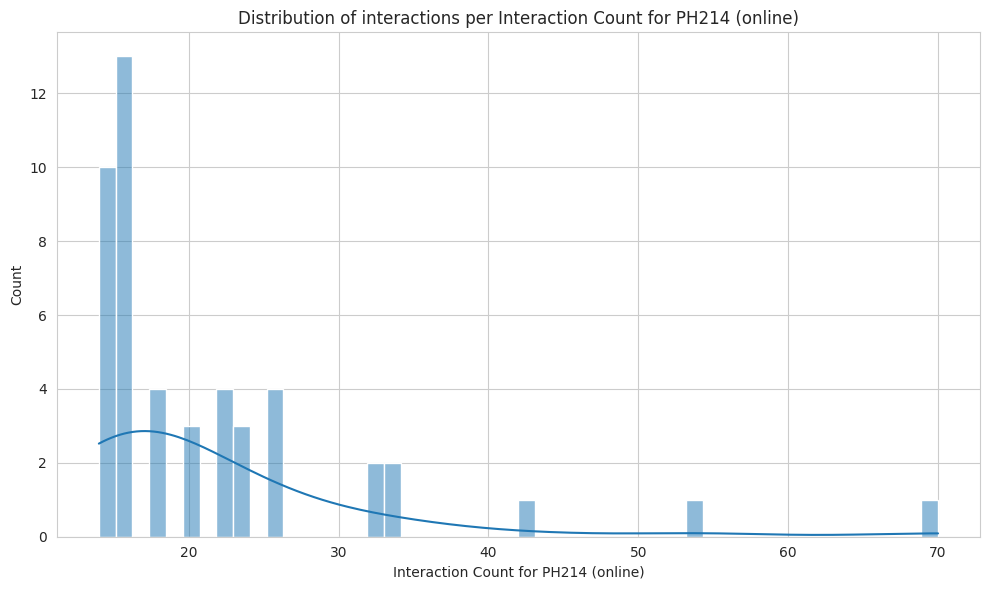

,interactions
count,48.000000
mean,21.708333
std,10.789984
min,14.000000
25%,16.000000
50%,18.000000
75%,24.000000
max,70.000000



--- Histogram for Course: PH215 (online) ---


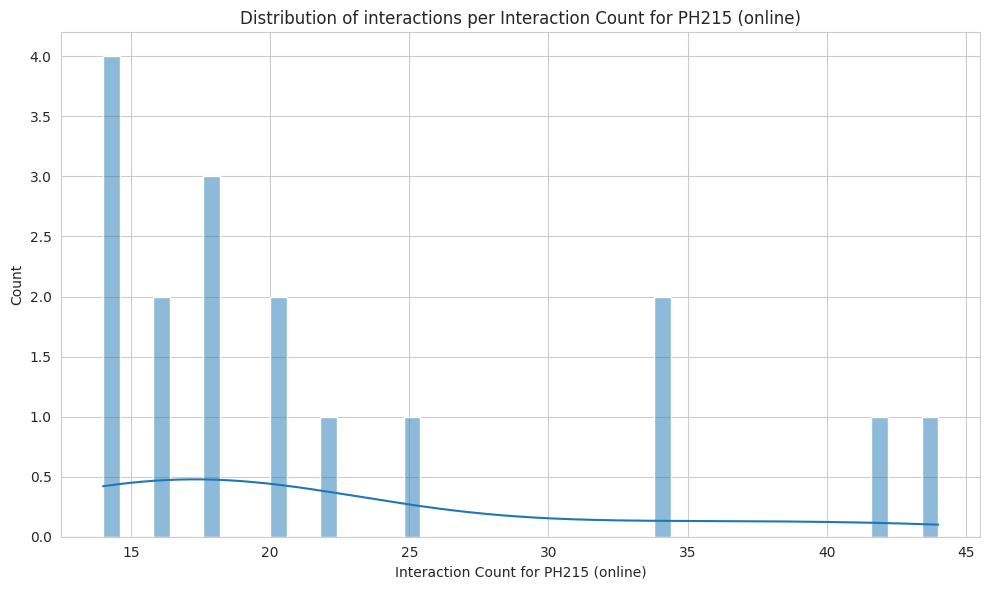

,interactions
count,17.000000
mean,22.529412
std,9.874953
min,14.000000
25%,16.000000
50%,18.000000
75%,25.000000
max,44.000000


In [13]:
# @title Histogram of all interactions {'run': 'auto', 'form-width': '20%'}

# By default, not dropping any counts under a certain threshold
drop_counts_under = 14 # @param {"type":"slider","min":0,"max":100,"step":1}

# Get unique courses from the unexploded_df
unique_courses = unexploded_df['Course'].unique()

for course in unique_courses:
  print(f"\n--- Histogram for Course: {course} ---")
  # Filter the DataFrame for the current course
  df_course = unexploded_df[unexploded_df['Course'] == course]
  # Call the analyze_hist function to plot the distribution of interactions for the current course
  analyze_hist(df_course, drop_counts_under, 'interactions', f'Interaction Count for {course}')

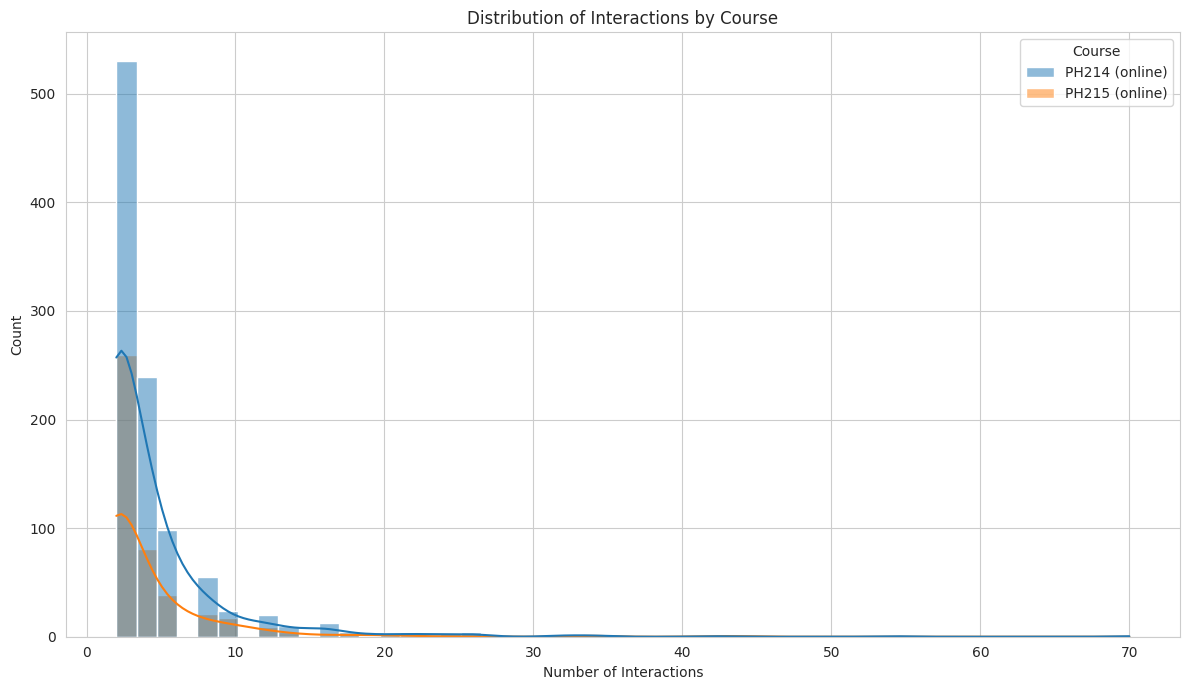

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))
sns.histplot(data=unexploded_df, x='interactions', hue='Course', bins=50, kde=True)
plt.title('Distribution of Interactions by Course')
plt.xlabel('Number of Interactions')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [15]:
print("----\n\n")

# x>40
group4 = unexploded_df[(unexploded_df['interactions']>40)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
print(f"above 40 interactions. count: {len(group4)}")
display(group4)


print("----\n\n")
# 20<=x<40
group3 = unexploded_df[(unexploded_df['interactions']<=40) & (unexploded_df['interactions']>19)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 20 and 40 interactions. count: {len(group3)}")
display(group3)

print("----\n\n")
# 2<x<=19
group2 = unexploded_df[(unexploded_df['interactions']<=19) & (unexploded_df['interactions']>6)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 6 and 19 interactions. count: {len(group2)}")
display(group2)

print("----\n\n")
# 2<x<=6
group5 = unexploded_df[(unexploded_df['interactions']<=6) & (unexploded_df['interactions']>2)][['user', 'Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 2 and 6 interactions. count: {len(group5)}")
display(group5)

print("----\n\n")
# 2>=x
group1 = unexploded_df[unexploded_df['interactions']<=2][['user','Course', 'lab_number', 'question_number', 'interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Less than 2 interactions. count: {len(group1)}")
display(group1)

----


above 40 interactions. count: 5


,user,Course,lab_number,question_number,interactions
816,159,PH214 (online),05,00,70
491,240,PH214 (online),05,00,54
1283,237,PH215 (online),05,00,44
757,256,PH214 (online),02,01,42
1324,256,PH215 (online),01,08,42


----


Between 20 and 40 interactions. count: 24


,user,Course,lab_number,question_number,interactions
337,237,PH214 (online),06,01,34
1451,305,PH215 (online),05,00,34
1326,256,PH215 (online),01,11,34
738,95,PH214 (online),01,01,34
717,144,PH214 (online),01,09,32
347,203,PH214 (online),01,00,32
1125,215,PH214 (online),06,05,26
749,256,PH214 (online),04,01,26
655,225,PH214 (online),03,02,26
720,144,PH214 (online),02,01,26


----


Between 6 and 19 interactions. count: 183


,user,Course,lab_number,question_number,interactions
420,239,PH214 (online),04,00,18
1403,139,PH215 (online),02,03,18
1385,139,PH215 (online),03,04,18
1201,263,PH214 (online),01,01,18
1606,333,PH215 (online),03,00,18
...,...,...,...,...,...
1598,326,PH215 (online),01,02,8
1607,333,PH215 (online),01,05,8
1611,333,PH215 (online),01,00,8
1664,314,PH215 (online),01,08,8


----


Between 2 and 6 interactions. count: 457


,user,Course,lab_number,question_number,interactions
92,234,PH214 (online),08,00,6
91,234,PH214 (online),06,06,6
82,234,PH214 (online),07,04,6
22,177,PH214 (online),01,03,6
1605,294,PH215 (online),01,05,6
...,...,...,...,...,...
854,139,PH214 (online),01,05,4
856,139,PH214 (online),03,05,4
782,91,PH214 (online),01,07,4
833,159,PH214 (online),06,06,4


----


Less than 2 interactions. count: 788


,user,Course,lab_number,question_number,interactions
1828,318,PH215 (online),06,11,2
1,141,PH214 (online),02,01,2
4,141,PH214 (online),01,04,2
5,141,PH214 (online),01,05,2
1732,331,PH215 (online),07,03,2
...,...,...,...,...,...
12,141,PH214 (online),01,09,2
11,141,PH214 (online),01,01,2
9,141,PH214 (online),01,10,2
8,141,PH214 (online),01,08,2


In [16]:
# @title count conversations by question {"form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the question sorted by lab, then number.

current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number', 'question_number', 'question', ])['thread'].nunique().reset_index().sort_values(by=['lab_number', 'question_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per question:")
# analyze_bar_graph(thread_counts_df, 'question', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique user counts per question:


,Course,lab_number,question_number,question,unique_thread_count
1,PH214 (online),01,01,PH214 (online) - Lab 01-Q01,61
2,PH214 (online),01,02,PH214 (online) - Lab 01-Q02,46
4,PH214 (online),01,04,PH214 (online) - Lab 01-Q04,40
3,PH214 (online),01,03,PH214 (online) - Lab 01-Q03,39
5,PH214 (online),01,05,PH214 (online) - Lab 01-Q05,35
...,...,...,...,...,...
99,PH215 (online),03,00,PH215 (online) - Lab 03-Q00,3
91,PH215 (online),02,09,PH215 (online) - Lab 02-Q09,2
12,PH214 (online),02,00,PH214 (online) - Lab 02-Q00,2
108,PH215 (online),04,02,PH215 (online) - Lab 04-Q02,2


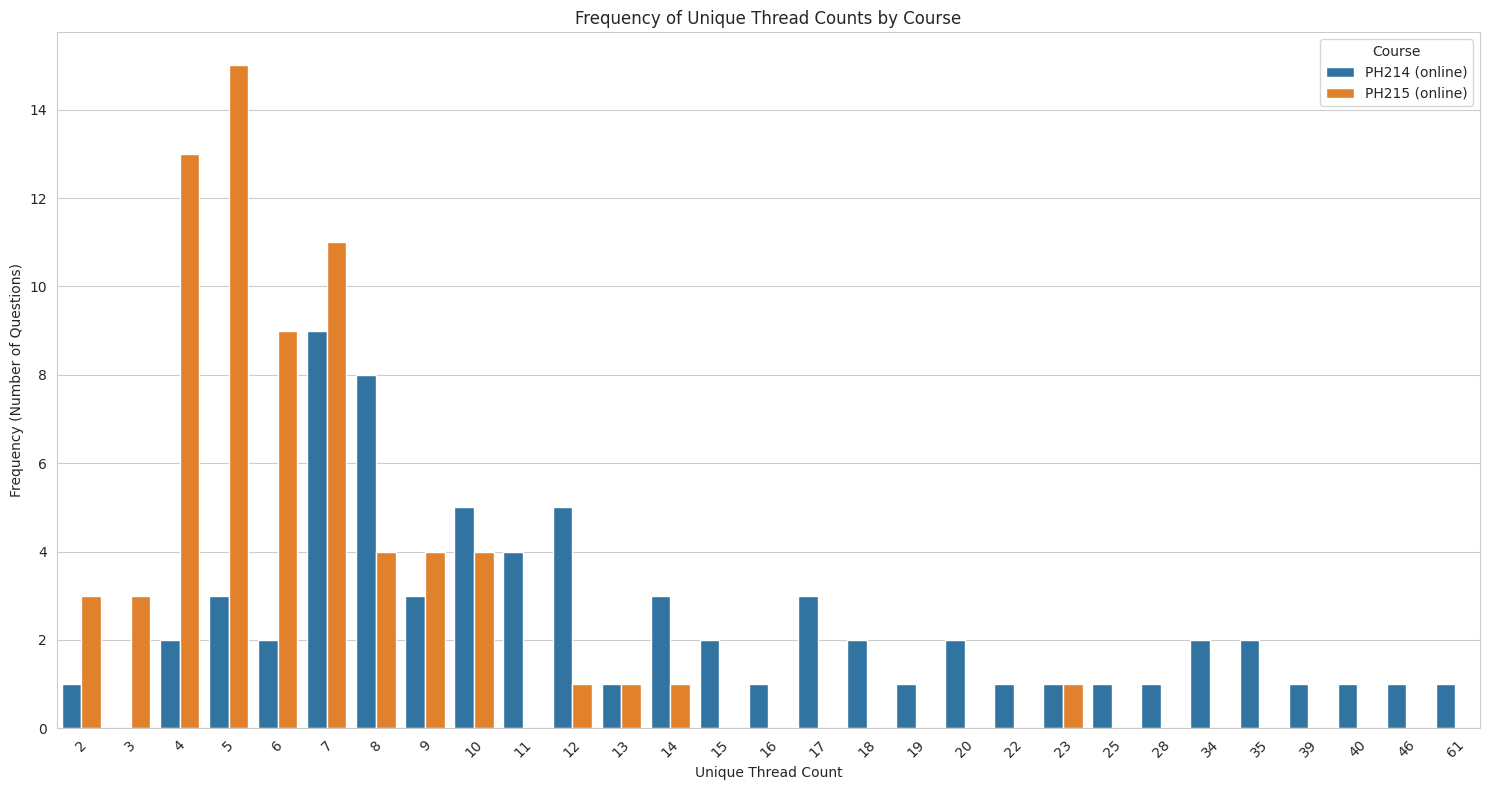

,Course,lab_number,question_number,question,unique_thread_count
1,PH214 (online),01,01,PH214 (online) - Lab 01-Q01,61
2,PH214 (online),01,02,PH214 (online) - Lab 01-Q02,46
4,PH214 (online),01,04,PH214 (online) - Lab 01-Q04,40
3,PH214 (online),01,03,PH214 (online) - Lab 01-Q03,39
5,PH214 (online),01,05,PH214 (online) - Lab 01-Q05,35
...,...,...,...,...,...
99,PH215 (online),03,00,PH215 (online) - Lab 03-Q00,3
91,PH215 (online),02,09,PH215 (online) - Lab 02-Q09,2
12,PH214 (online),02,00,PH214 (online) - Lab 02-Q00,2
108,PH215 (online),04,02,PH215 (online) - Lab 04-Q02,2


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plot
sns.set_style("whitegrid")

# Preprocess data to count frequencies for barplot
barplot_data = thread_counts_df.groupby(['Course', 'unique_thread_count']).size().reset_index(name='frequency')

plt.figure(figsize=(15, 8))
sns.barplot(data=barplot_data, x='unique_thread_count', y='frequency', hue='Course', dodge=True)
plt.title('Frequency of Unique Thread Counts by Course')
plt.xlabel('Unique Thread Count')
plt.ylabel('Frequency (Number of Questions)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique user counts per lab:


,Course,lab_number,unique_thread_count
0,PH214 (online),01,405
1,PH214 (online),02,160
8,PH215 (online),01,130
5,PH214 (online),06,122
6,PH214 (online),07,107
3,PH214 (online),04,96
2,PH214 (online),03,94
9,PH215 (online),02,87
13,PH215 (online),06,74
14,PH215 (online),07,53


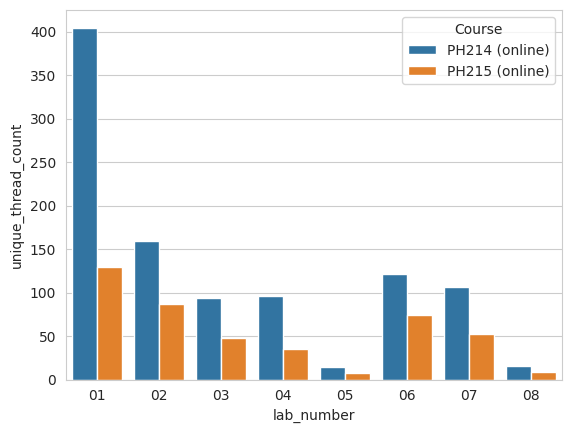

In [18]:
# @title count conversations by lab_number {"form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown the x axis represents the lab number.

current_df = combined_df

thread_counts_df = current_df.groupby(['Course', 'lab_number'])['thread'].nunique().reset_index().sort_values(by=['lab_number'])
thread_counts_df.rename(columns={'thread': 'unique_thread_count'}, inplace=True)
# thread_counts_df = thread_counts_df.sort_values(by=['question'])
print("Unique user counts per lab:")
sns.barplot(data=thread_counts_df, x='lab_number', y='unique_thread_count', hue='Course', dodge=True)
# analyze_bar_graph(thread_counts_df, 'lab_number', 'unique_thread_count', 'Conversation Count by Question', tick_label_size=7)
display(thread_counts_df.sort_values(by=['unique_thread_count'], ascending=False))


Unique thread counts per user and lab_number:


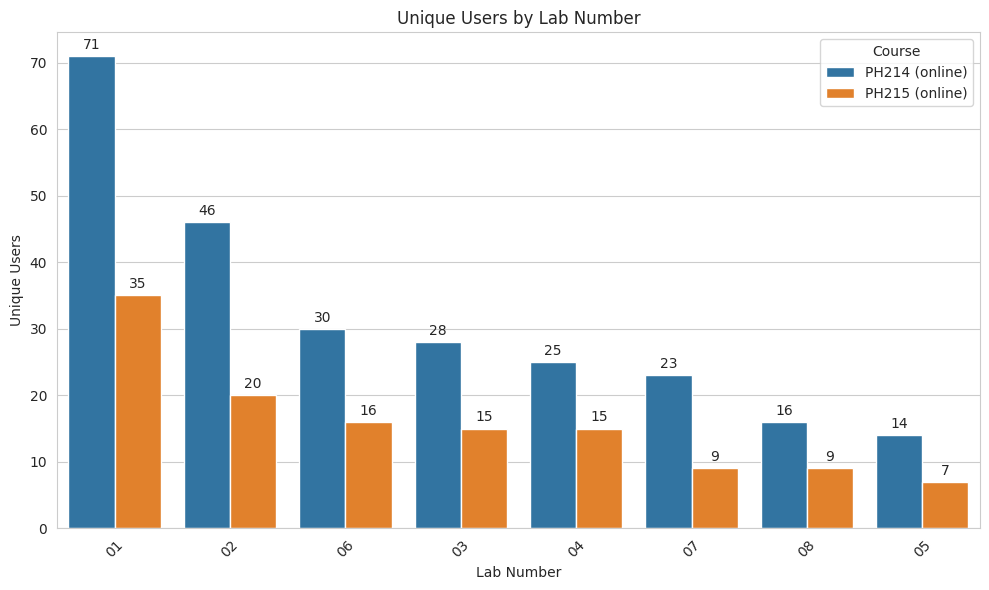

,Course,lab_number,unique_users
0,PH214 (online),01,71
1,PH214 (online),02,46
8,PH215 (online),01,35
5,PH214 (online),06,30
2,PH214 (online),03,28
3,PH214 (online),04,25
6,PH214 (online),07,23
9,PH215 (online),02,20
13,PH215 (online),06,16
7,PH214 (online),08,16


In [26]:
# @title count users per lab {"form-width":"20%"}

current_df = combined_df

lab_counts_df = current_df.groupby(['Course', 'lab_number'])['user'].nunique().reset_index()
lab_counts_df.rename(columns={'user': 'unique_users'}, inplace=True)
lab_counts_df = lab_counts_df[['Course', 'lab_number','unique_users']].sort_values(by=['unique_users'], ascending=False)
print("Unique thread counts per user and lab_number:")

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=lab_counts_df, x='lab_number', y='unique_users', hue='Course', dodge=True)

# Add numbers on top of the bars
ax = plt.gca()
for container in ax.containers:
    for patch in container.patches:
        height = patch.get_height()
        ax.annotate(f'{int(height)}',
                    xy=(patch.get_x() + patch.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

plt.title('Unique Users by Lab Number')
plt.xlabel('Lab Number')
plt.ylabel('Unique Users')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# analyze_bar_graph(lab_counts_df,'lab_number', 'unique_users', "Unique users by Lab numbers")
display(lab_counts_df)

Unique thread per user


,user,unique_threads
76,252,63
121,331,63
86,139,60
30,139,59
75,245,55
...,...,...
84,136,1
68,235,1
110,312,1
102,278,1


----


greater or equal to 45 conversations. count: 5


,user,unique_threads
76,252,63
121,331,63
86,139,60
30,139,59
75,245,55


----


Between 22 and 45 conversations. count: 14


...

,user,unique_threads
4,85,21
43,174,21
17,106,20
20,111,20
87,156,18
80,263,17
71,239,17
8,91,17
59,219,16
112,314,16


----


Between 5 and 13 conversations. count: 38


,user,unique_threads
60,222,12
49,188,12
13,101,12
115,318,12
118,325,12
31,141,12
36,151,12
9,92,11
122,332,11
77,256,11


----


Less than 5. count: 53


,user,unique_threads
34,147,4
83,122,4
108,301,4
96,237,4
98,244,4
41,167,4
7,90,4
56,209,3
111,313,3
2,83,3


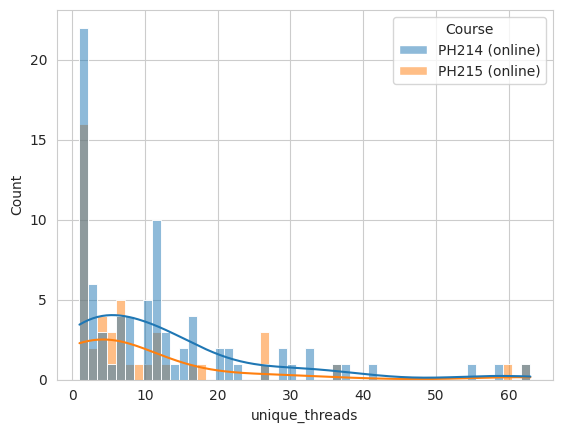

In [20]:
# @title count conversations by user {"run":"auto","form-width":"20%"}

drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}
# @markdown "4 groups: x<5, 5<x<13, 13<x<22, 22<x<45, 45<x"
filter_by_lab_number = "False" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}

# Call the function with the relevant DataFrame and parameter

current_df = combined_df
if filter_by_lab_number != "False":
  current_df = current_df[current_df['lab_number'] < filter_by_lab_number]

lab_counts_df = current_df.groupby(['Course','user'])['thread'].nunique().reset_index()
lab_counts_df.rename(columns={'thread': 'unique_threads'}, inplace=True)

lab_counts_df = lab_counts_df.sort_values(by='unique_threads', ascending=False)

print("Unique thread per user")
import ipywidgets as widgets
from IPython.display import display

# analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user'
# analyze_hist(lab_counts_df, drop_counts_under,'unique_threads','user')
sns.histplot(data=lab_counts_df, x='unique_threads', hue='Course', bins=50, kde=True)

# analyze_bar_graph(lab_counts_df,'user', 'unique_threads', "Unique threads per user")
display(lab_counts_df[['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False))

print("----\n\n")
# x>=45
group5 = lab_counts_df[lab_counts_df['unique_threads']>=45][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"greater or equal to 45 conversations. count: {len(group5)}")
display(group5)

print("----\n\n")
# 22<=x<45
group4 = lab_counts_df[(lab_counts_df['unique_threads']<45) & (lab_counts_df['unique_threads']>=22)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 22 and 45 conversations. count: {len(group4)}")
display(group4)


print("----\n\n")
# 13<=x<22
group3 = lab_counts_df[(lab_counts_df['unique_threads']<22) & (lab_counts_df['unique_threads']>=13)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 13 and 22 conversations. count: {len(group3)}")
display(group3)

print("----\n\n")
# 5<=x<13
group2 = lab_counts_df[(lab_counts_df['unique_threads']<13) & (lab_counts_df['unique_threads']>=5)][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Between 5 and 13 conversations. count: {len(group2)}")
display(group2)

print("----\n\n")
# 5>x
group1 = lab_counts_df[lab_counts_df['unique_threads']<5][['user','unique_threads']].sort_values(by=['unique_threads'], ascending=False)
print(f"Less than 5. count: {len(group1)}")
display(group1)


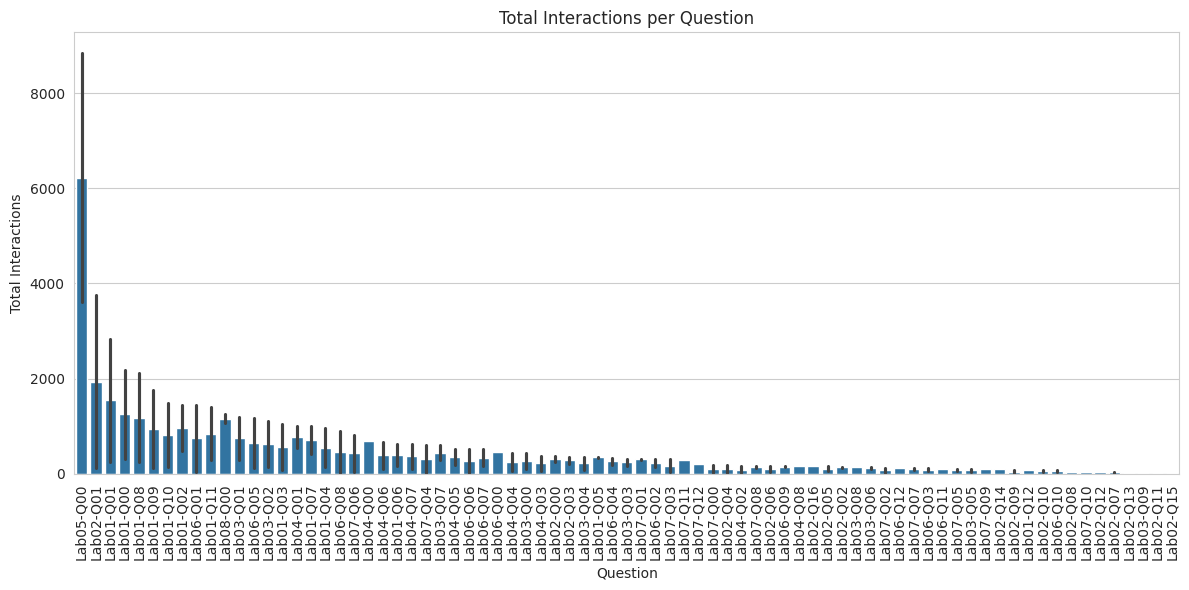

,full_question,interactions
43,Lab05-Q00,8836
13,Lab02-Q01,3748
114,Lab05-Q00,3612
1,Lab01-Q01,2836
0,Lab01-Q00,2184
...,...,...
93,Lab02-Q11,16
121,Lab06-Q06,16
97,Lab02-Q15,16
91,Lab02-Q09,8


In [45]:
# @title Total Interactions by Question Plot {"form-width":"20%"}

current_df = combined_df

interactions_by_question = current_df.groupby(['Course', 'lab_number', 'question_number', 'question_text'])['interactions'].sum().reset_index()

# Create a combined question identifier for the x-axis labels if needed, or use existing columns
interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_question,
    x_col='full_question',
    y_col='interactions',
    title='Total Interactions per Question',
    x_label='Question',
    y_label='Total Interactions'
)
interactions_by_question = interactions_by_question.sort_values(by='interactions', ascending=False)
display(interactions_by_question[['full_question','interactions']])


# @markdown ---
export_table = False # @param {"type":"boolean"}
output_name = "conversations_by_question" # @param {"type":"string","placeholder":"Enter the name of the csv file"}
target_folder_link = "https://drive.google.com/drive/folders/1Jz9QrU0ZmhCQn4GWh_wa9WtUPzcW2s-s?usp=drive_link" # @param {"type":"string","placeholder":"Enter YOUR_GOOGLE_DRIVE_FOLDER_ID_HERE"}

if export_table:
  export_data_csv(interactions_by_question[['full_question','interactions']],output_name, target_folder_link)

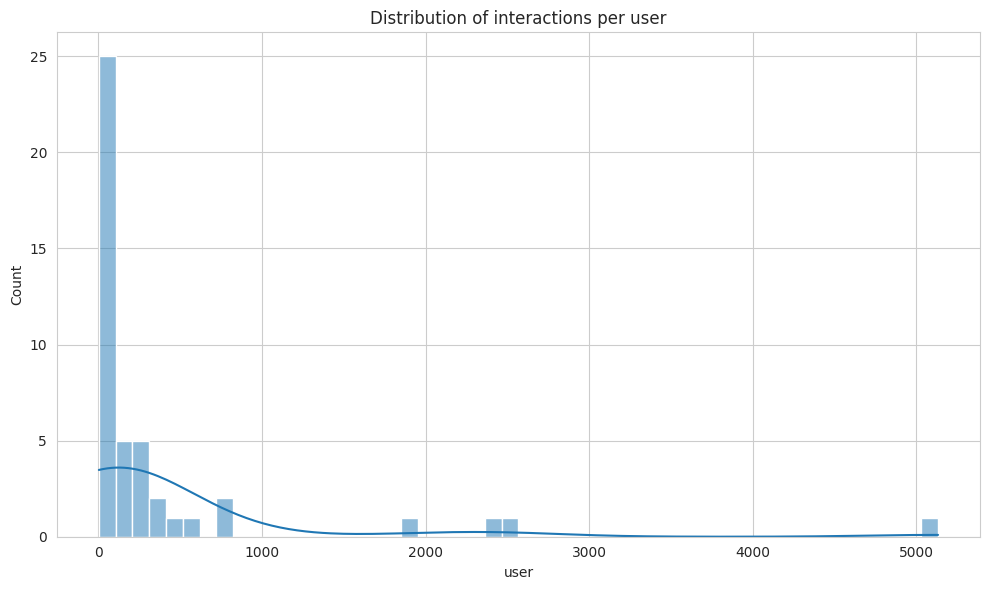

,interactions
count,45.000000
mean,405.377778
std,918.490394
min,4.000000
25%,36.000000
50%,68.000000
75%,300.000000
max,5132.000000


,user,interactions
17,256,5132
27,305,2493
14,237,2389
4,139,1940
39,331,732
41,333,724
6,159,585
21,281,480
11,222,412
30,314,376


----


greater or equal to 229 conversations. count: 15


,user,interactions
17,256,5132
27,305,2493
14,237,2389
4,139,1940
39,331,732
41,333,724
6,159,585
21,281,480
11,222,412
30,314,376


----


Between 104 and 229 conversations. count: 6


...

,user,interactions
18,260,96
29,313,68
31,315,61
7,174,60
32,317,52


----


Between 7 and 50 conversations. count: 15


,user,interactions
33,318,48
19,276,44
38,328,44
44,339,40
16,244,40
8,182,36
23,294,36
10,201,36
35,324,32
9,188,20


----


Less than 7. count: 4


,user,interactions
0,84,4
2,136,4
28,312,4
20,278,4


In [48]:
# @title Total Interactions by User Plot {"run":"auto","form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}

current_df = combined_df
current_df=current_df[current_df['Course']=='PH215 (online)']
interactions_by_user = current_df.groupby(['user'])['interactions'].sum().reset_index()

# Create a combined question identifier for the x-axis labels if needed, or use existing columns
# interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
# analyze_bar_graph(
#     df=interactions_by_user,
#     x_col='user',
#     y_col='interactions',
#     title='Total Interactions per User',
#     x_label='User',
#     y_label='Total Interactions'
# )
analyze_hist(interactions_by_user, drop_counts_under,'interactions','user')
interactions_by_user = interactions_by_user.sort_values(by='interactions', ascending=False)
display(interactions_by_user[['user','interactions']])
#############################
print("----\n\n")
# x>=45
group5 = interactions_by_user[interactions_by_user['interactions']>=229][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"greater or equal to 229 conversations. count: {len(group5)}")
display(group5)

print("----\n\n")
# 22<=x<45
group4 = interactions_by_user[(interactions_by_user['interactions']<229) & (interactions_by_user['interactions']>=104)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 104 and 229 conversations. count: {len(group4)}")
display(group4)


print("----\n\n")
# 13<=x<22
group3 = interactions_by_user[(interactions_by_user['interactions']<104) & (interactions_by_user['interactions']>=50)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 50 and 104 conversations. count: {len(group3)}")
display(group3)

print("----\n\n")
# 5<=x<13
group2 = interactions_by_user[(interactions_by_user['interactions']<50) & (interactions_by_user['interactions']>=7)][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Between 7 and 50 conversations. count: {len(group2)}")
display(group2)

print("----\n\n")
# 5>x
group1 = interactions_by_user[interactions_by_user['interactions']<7][['user','interactions']].sort_values(by=['interactions'], ascending=False)
print(f"Less than 7. count: {len(group1)}")
display(group1)

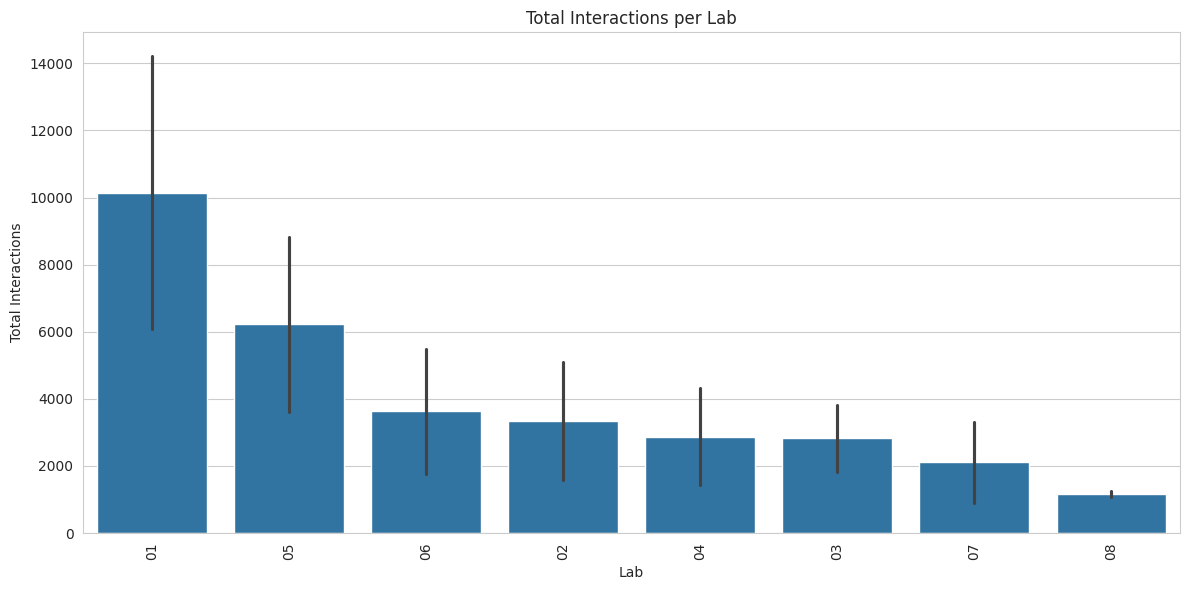

,lab_number,interactions_by_lab
0,01,14212
4,05,8836
8,01,6076
5,06,5492
1,02,5108
3,04,4320
2,03,3820
12,05,3612
6,07,3320
10,03,1825


In [28]:
# @title Total Interactions by Question Plot {"run":"auto","form-width":"20%"}
drop_counts_under = 0 # @param {"type":"slider","min":0,"max":100,"step":1}

current_df = combined_df

interactions_by_lab = current_df.groupby(['Course', 'lab_number'])['interactions'].sum().reset_index()
interactions_by_lab.rename(columns={'interactions': 'interactions_by_lab'}, inplace=True)
# Create a combined question identifier for the x-axis labels if needed, or use existing columns
# interactions_by_question['full_question'] = 'Lab' + interactions_by_question['lab_number'] + '-Q' + interactions_by_question['question_number']
analyze_bar_graph(
    df=interactions_by_lab,
    x_col='lab_number',
    y_col='interactions_by_lab',
    title='Total Interactions per Lab',
    x_label='Lab',
    y_label='Total Interactions'
)
interactions_by_lab = interactions_by_lab.sort_values(by='interactions_by_lab', ascending=False)
display(interactions_by_lab[['lab_number','interactions_by_lab']])

In [24]:
# @title last lab {"run":"auto","form-width":"20%"}
current_df = combined_df
filter_by_lab_number = "04" # @param ["01","02","03","04","05","06","07","08","False"] {"allow-input":true}


last_lab_per_user = current_df.groupby('user')['lab_number'].max().reset_index()
last_lab_per_user.rename(columns={'lab_number': 'last_lab_number'}, inplace=True)
if filter_by_lab_number != "False":
  last_lab_per_user = last_lab_per_user[last_lab_per_user['last_lab_number'] == filter_by_lab_number]

print("Last (highest) lab number for each user:")
display(last_lab_per_user.sort_values(by='last_lab_number', ascending=False))

Last (highest) lab number for each user:


,user,last_lab_number
1,79,04
13,101,04
32,144,04
46,182,04
69,236,04
94,315,04


In [25]:
# from google.colab import sheets

# # @title Create Interactive Sheet and optionally move to a specific folder {"form-width":"20%"}
# move_to_target_folder = True # @param {type:"boolean"}
# target_folder_for_sheet_link = "https://drive.google.com/drive/folders/1KeIQKtAkXxhU6mB8uzd8Nw3_Ji7Oroyx?usp=drive_link" # @param {type:"string"}
# sheet_name = "transcript_analysis_Jan14" # @param {"type":"string"}

# # Create the interactive sheet
# sheet_object = sheets.InteractiveSheet(title=sheet_name, include_column_headers=True, df=combined_df)

# # Get the ID of the newly created sheet
# sheet_id = sheet_object.id
# print(f"Interactive Sheet created with ID: {sheet_id}")
# print(f"Interactive Sheet URL: {sheet_object.url}")

# if move_to_target_folder:
#   if 'GDM' not in globals():
#     GDM = GoogleDocumentManager(SERVICE_ACCOUNT_FILE)

#   target_folder_id = extract_file_id(target_folder_for_sheet_link)
#   if target_folder_id:
#     try:
#       # Get current parent(s) to remove from
#       current_parents = GDM.get_file_parent_info(file_id=sheet_id)['parents']
#       current_parent_ids = [p['id'] for p in current_parents]

#       # Move the file by updating its parents
#       GDM.update_file_metadata(
#           file_id=sheet_id,
#           add_parents=target_folder_id,
#           remove_parents=','.join(current_parent_ids)
#       )
#       print(f"Successfully moved Interactive Sheet (ID: {sheet_id}) to folder (ID: {target_folder_id})")
#     except Exception as e:
#       print(f"Error moving sheet to target folder: {e}")
#       print("Please ensure the target folder link is valid and you have appropriate permissions.")
#   else:
#     print(f"Invalid target folder link provided: {target_folder_for_sheet_link}")
